In [36]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    print(root, len(files), 'files')

/kaggle/input 0 files
/kaggle/input/datasets 0 files
/kaggle/input/datasets/ipythonx 0 files
/kaggle/input/datasets/ipythonx/mvtec-ad 2 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood 2 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth 0 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole 10 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/liquid 10 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/scratch 21 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/color 8 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/combined 11 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/test 0 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/test/good 19 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/test/hole 10 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/test/liquid 10 files
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/test/scratch 21 files
/kaggle/input/datasets/ipythonx/mvtec-a

In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob
import os

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [38]:
# UPDATE THIS PATH after checking your dataset structure with os.walk
BASE_PATH = '/kaggle/input/datasets/ipythonx/mvtec-ad/bottle'  

TRAIN_GOOD = os.path.join(BASE_PATH, 'train', 'good')
TEST_DIR = os.path.join(BASE_PATH, 'test')

print("Train good images:", len(os.listdir(TRAIN_GOOD)))
print("Test subfolders:", os.listdir(TEST_DIR))

Train good images: 209
Test subfolders: ['good', 'contamination', 'broken_large', 'broken_small']


In [39]:
IMG_SIZE = 128  # resize target

def load_images(folder_path, img_size=IMG_SIZE):
    images = []
    filepaths = glob.glob(os.path.join(folder_path, '*.png'))
    for fp in filepaths:
        img = Image.open(fp).convert('RGB')
        img = img.resize((img_size, img_size))
        img_array = np.array(img) / 255.0  # normalize to [0,1]
        images.append(img_array)
    return np.array(images, dtype=np.float32)

# Load only NORMAL images for training
X_train = load_images(TRAIN_GOOD)
print("Training data shape:", X_train.shape)  # should be (N, 128, 128, 3)

Training data shape: (209, 128, 128, 3)


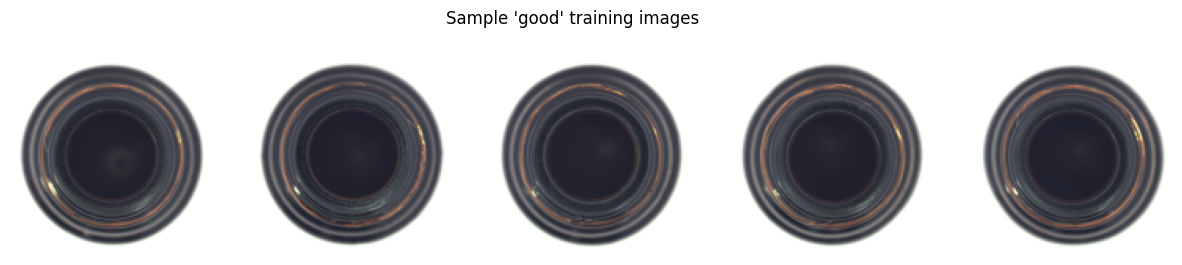

In [40]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i])
    ax.axis('off')
plt.suptitle("Sample 'good' training images")
plt.show()

In [41]:
def build_autoencoder(img_size=IMG_SIZE):
    input_img = layers.Input(shape=(img_size, img_size, 3))

    # Encoder
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D(2, padding='same')(x)  # bottleneck

    # Decoder
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    decoded = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 285ms/step - loss: 0.1002 - val_loss: 0.0586
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0459 - val_loss: 0.0459
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0277 - val_loss: 0.0205
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0172 - val_loss: 0.0135
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0106 - val_loss: 0.0072
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0055 - val_loss: 0.0038
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0037 - val_loss: 0.0035
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0030 - val_loss: 0.0027
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/ste

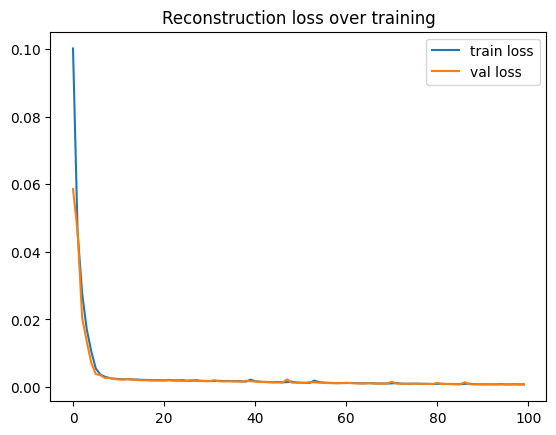

In [42]:
history = autoencoder.fit(
    X_train, X_train,          # input = target (that's the "auto" in autoencoder)
    epochs=100,
    batch_size=16,
    shuffle=True,
    validation_split=0.1
)

# Plot training loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Reconstruction loss over training')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step


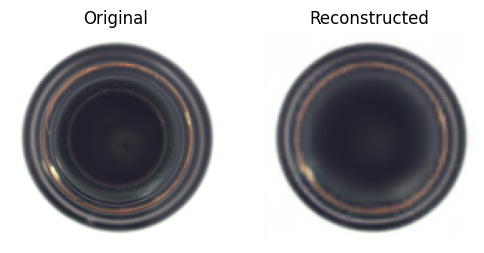

In [43]:
sample = X_train[0:1]  # take one training image
reconstructed = autoencoder.predict(sample)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(sample[0])
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(reconstructed[0])
axes[1].set_title("Reconstructed")
axes[1].axis('off')
plt.show()

In [44]:
def load_test_images_with_labels(test_dir, img_size=IMG_SIZE):
    images = []
    labels = []  # 0 = good, 1 = defective
    defect_types = []

    for subfolder in os.listdir(test_dir):
        folder_path = os.path.join(test_dir, subfolder)
        filepaths = glob.glob(os.path.join(folder_path, '*.png'))
        label = 0 if subfolder == 'good' else 1

        for fp in filepaths:
            img = Image.open(fp).convert('RGB')
            img = img.resize((img_size, img_size))
            img_array = np.array(img) / 255.0
            images.append(img_array)
            labels.append(label)
            defect_types.append(subfolder)

    return np.array(images, dtype=np.float32), np.array(labels), defect_types

X_test, y_test, defect_types = load_test_images_with_labels(TEST_DIR)
print("Test set shape:", X_test.shape)
print("Normal:", np.sum(y_test == 0), "| Defective:", np.sum(y_test == 1))

Test set shape: (83, 128, 128, 3)
Normal: 20 | Defective: 63


In [45]:
reconstructions = autoencoder.predict(X_test)

# Per-image reconstruction error (mean squared error across all pixels)
errors = np.mean(np.square(X_test - reconstructions), axis=(1, 2, 3))

# Quick look: are defective images scoring higher error than good ones?
print("Mean error (good):", errors[y_test == 0].mean())
print("Mean error (defective):", errors[y_test == 1].mean())

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step
Mean error (good): 0.0009455164
Mean error (defective): 0.0014390107


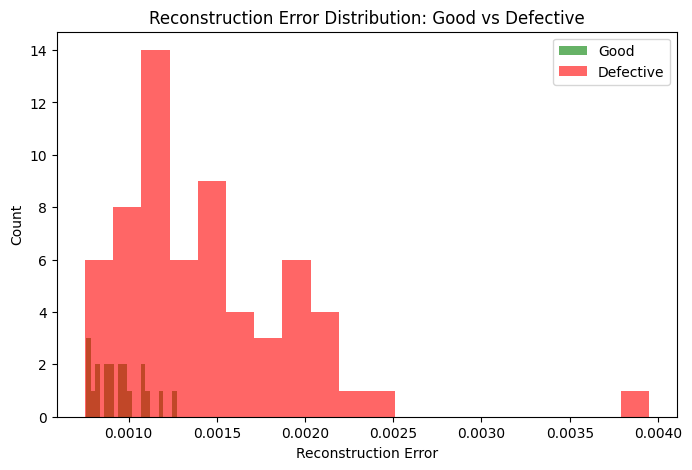

In [46]:
plt.figure(figsize=(8, 5))
plt.hist(errors[y_test == 0], bins=20, alpha=0.6, label='Good', color='green')
plt.hist(errors[y_test == 1], bins=20, alpha=0.6, label='Defective', color='red')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.title('Reconstruction Error Distribution: Good vs Defective')
plt.legend()
plt.show()

ROC-AUC: 0.861


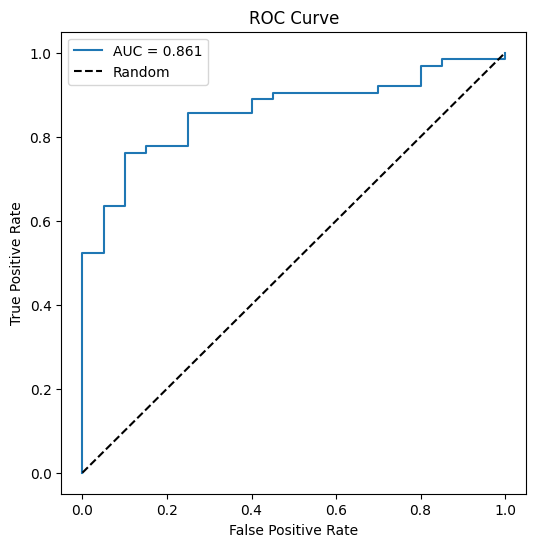

In [47]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

auc = roc_auc_score(y_test, errors)
print(f"ROC-AUC: {auc:.3f}")

fpr, tpr, thresholds = roc_curve(y_test, errors)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [48]:
import pandas as pd

df = pd.DataFrame({
    'error': errors,
    'label': y_test,
    'defect_type': defect_types
})

print(df.groupby('defect_type')['error'].agg(['mean', 'median', 'count']))

                   mean    median  count
defect_type                             
broken_large   0.001463  0.001444     20
broken_small   0.001394  0.001256     22
contamination  0.001464  0.001305     21
good           0.000946  0.000922     20


In [49]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, errors)

# Find threshold that gives at least 90% recall (catch 90%+ of real defects)
target_recall = 0.90
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(precisions[valid_idx])]  # highest precision among those
    chosen_threshold = pr_thresholds[best_idx]
else:
    chosen_threshold = np.median(errors)  # fallback

print(f"Chosen threshold: {chosen_threshold:.5f}")

y_pred = (errors >= chosen_threshold).astype(int)
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1: {f1_score(y_test, y_pred):.3f}")

Chosen threshold: 0.00094
Precision: 0.864
Recall: 0.905
F1: 0.884


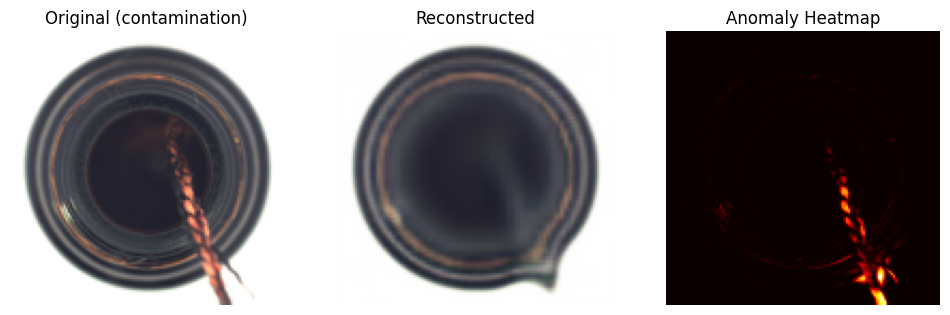

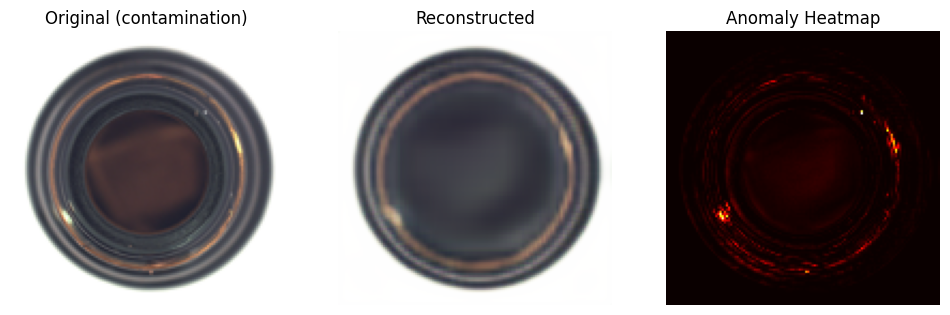

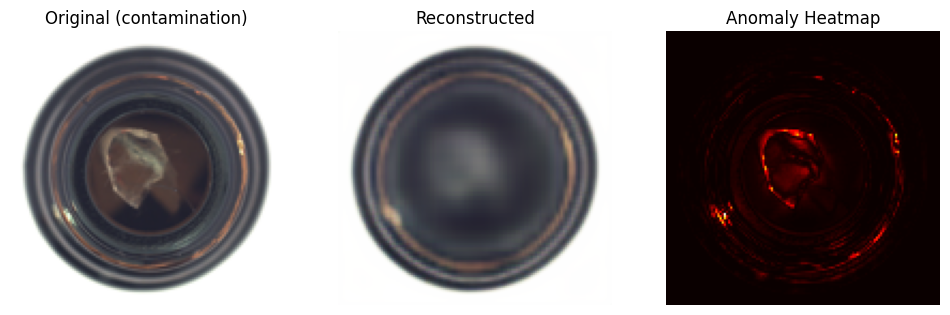

In [50]:
def show_anomaly_map(idx):
    original = X_test[idx]
    recon = reconstructions[idx]
    error_map = np.mean(np.square(original - recon), axis=-1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original); axes[0].set_title(f"Original ({defect_types[idx]})"); axes[0].axis('off')
    axes[1].imshow(recon); axes[1].set_title("Reconstructed"); axes[1].axis('off')
    axes[2].imshow(error_map, cmap='hot'); axes[2].set_title("Anomaly Heatmap"); axes[2].axis('off')
    plt.show()

defective_idxs = np.where(y_test == 1)[0]
for i in defective_idxs[:3]:
    show_anomaly_map(i)

In [51]:
autoencoder.save('/kaggle/working/bottle_autoencoder.h5')
print("Model saved")

Model saved
